In [1]:
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram, linkage
import numpy as np

**Generating sample data:**

(150, 2)


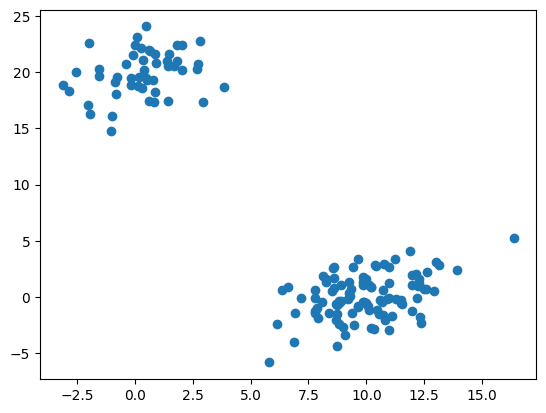

In [3]:
np.random.seed(4711)  
a = np.random.multivariate_normal([10, 0], [[3, 1], [1, 4]], size=[100,])
b = np.random.multivariate_normal([0, 20], [[3, 1], [1, 4]], size=[50,])
X = np.concatenate((a, b),)
print(X.shape)  # 150 samples with 2 dimensions
plt.scatter(X[:,0], X[:,1])
plt.show()

**Perform the hierarchical clustering:**

In [4]:
# generate the linkage matrix:
Z = linkage(X, 'ward')

scipy.cluster.hierarchy.linkage() => is doing agglomerative clustering. 
- starts with every data point as its own cluster, then repeatedly merges the closest clusters until everything becomes one big cluster
- returned matrix is a log of the merge operations
- Imagine 4 points: X = [[1],[2],[10],[11]]
  - Initially, cluster 0 => point 1 | cluster 1 => point 2 | cluster 2 => point 10 | cluster 3 => point 11
  - Then linkage asks:
    - which 2 clusters are closest right now => merge them => then repeat
  - What linkage returns:
    - Z = linkage(X, method="single")
    - returns a matrix of shape (n-1, 4)
    - this is because, for n points, there's always n-1 merges needed to end with one cluster
    - so, if n = 4 | we end up with (3,4)
    - Meaning of each row:
      - each row means: [cluster_a, cluster_b, distance, new_cluster_size]
      - So:
          - column 1: first cluster merged | column 2: second cluster merged | column 3: distance at which they merged | column 4: number of original points inside new cluster
          - Imagine result: Z =
                                [[0. 1. 1. 2.]
                                [2. 3. 1. 2.]
                                [4. 5. 8. 4.]]
          - Row 1: [0, 1, 1, 2] => merge point 0 and point 1 | distance = 1 | creates new cluster 4. ($ because the original points were 0,1,2,3 | now, new clusters start at n=4)
          - Cluster 4 contains 2 points
    - What the distanc means depends on method:
      - Single linkage: Distance between clusters = closest pair of points
      - Complete linkage: Distance = farthest pair of points
      - Average linkage: Average of all pairwise distances
      - Ward: merges clusters that minimally increase variance
- so linkage methods come in when singletons are merged to clusters and we're now comparing inter-cluster distances where we look at whether to define that distance by nearest nighbor points(single), farthest points (complete), average distance between all points (average) and thena metric that minimizes within cluster variance after a merge (ward)

Cophenetic Correlation Coefficient: 
- The cophenetic correlation coefficient is a way to measure:
  - how faithfully your dendrogram/hierarchical clustering tree preserves the original pairwise distances between data points. 
  - It is a quality check for the tree structure, not directly "how good the clusters are" not directly how good the clusters are in a business sense
- **Why it exists:**
 - running hierarchical clustering (via linkage) turns raw distances between points into a merge tree (dendrogram)
 - The tree is a simplification | The question asked is: Does this tree reflect the actual geometry of the data or does it distort the relationships
 - CCC answers that. 
 - Cophenetic distances: distance implied by the dendrogram | for any two points: At what merge height do these two points first become part of the same cluster | that merge height = their cophenetic distance
 - Core intuition: 
   - Cophenetic correlation coefficient computes the correlation between the original inter-cluster distances computed using the distance metric of choice and the cophenetic distances (distances on the dendrogram when the clusters merged)
- One of the main practical uses of the **Cophenetic Correlation coefficient** is to compare linkage methods...as the cophenetic correlation coefficient shows how the resultant linkage how representative that is of the original dataset. so we can try different linkage methods that we think might work for a particular dataset and then choose the one with the best cophenetic correlation coefficient...

In [6]:
# we now compute the cophenetic correlation coefficient which correlates the actualpairwise distances of all samples in the data to those implied by the hierarchical clustering (cophenetic distances)
# the closer the value is to 1, the better the clustering preserves the original distances, which in our case is close to 1
from scipy.cluster.hierarchy import cophenet
from scipy.spatial.distance import pdist

c, coph_dists = cophenet(Z, pdist(X))

In [7]:
c

0.9800148387574268

In [9]:
coph_dists

array([ 1.49619316, 23.12198936,  6.44511711, ...,  0.85438969,
        1.7940741 ,  1.7940741 ])

In [12]:
Z[0]

array([5.20000000e+01, 5.30000000e+01, 4.15105485e-02, 2.00000000e+00])

**Plotting a Dendrogram:**

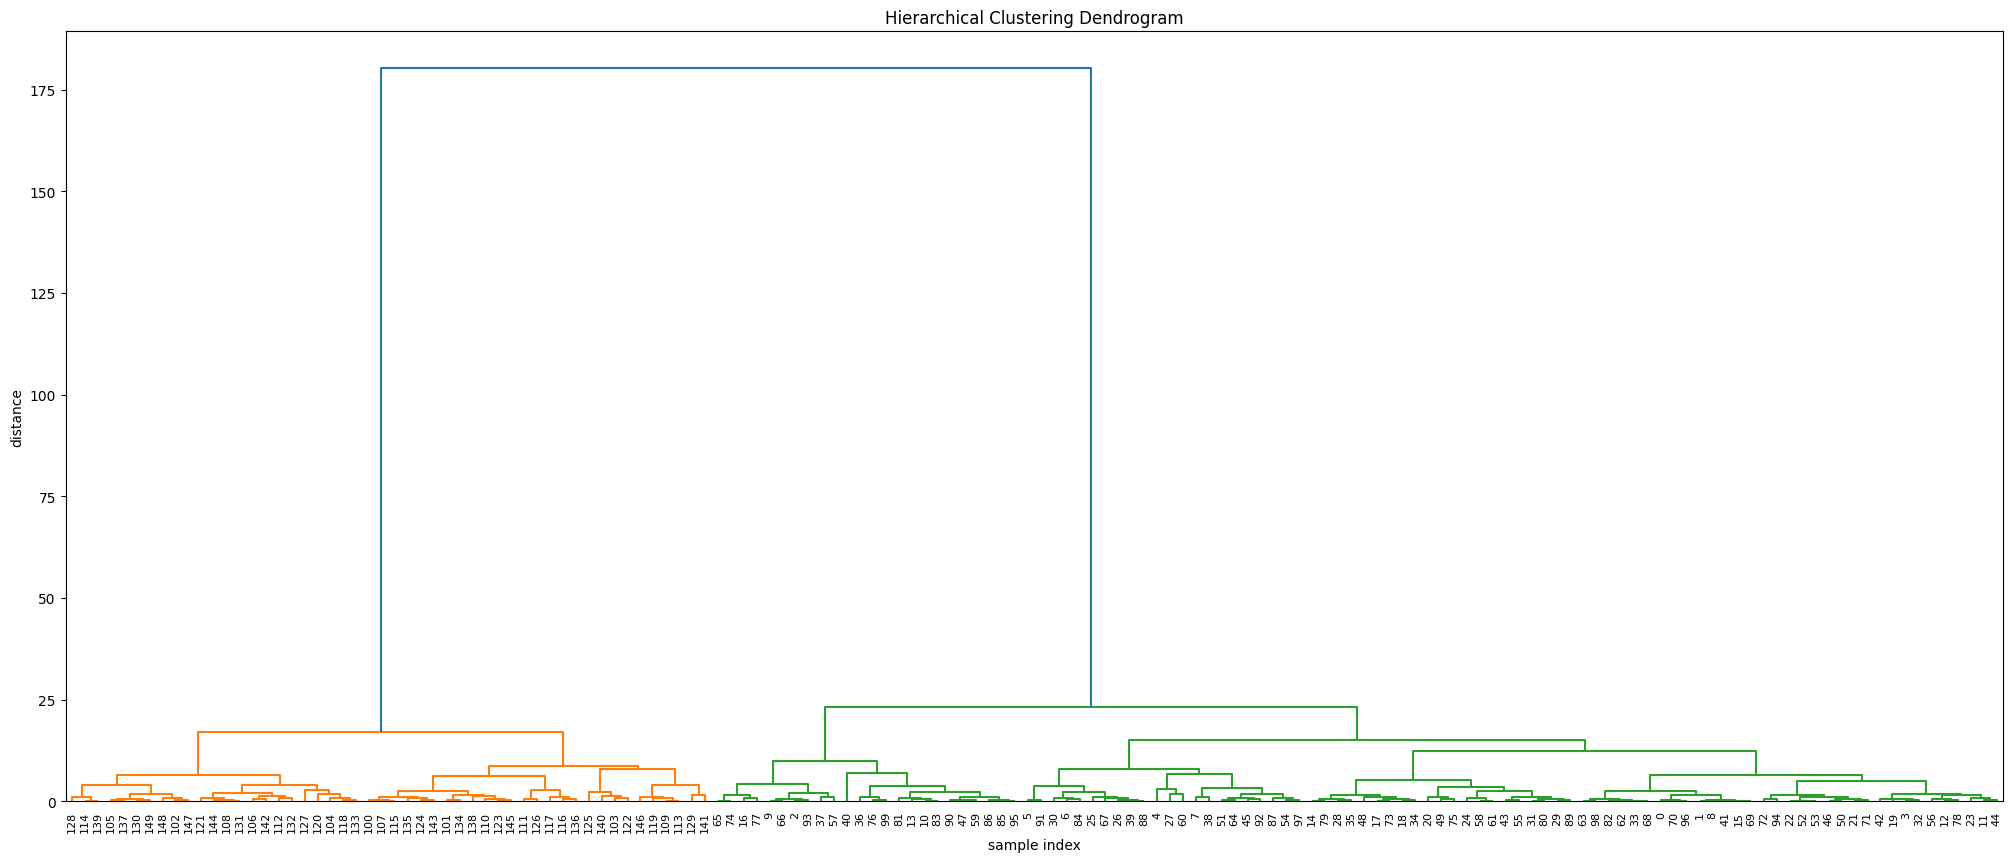

In [13]:
plt.figure(figsize=(25,10))
plt.title('Hierarchical Clustering Dendrogram')
plt.xlabel('sample index')
plt.ylabel('distance')
dendrogram(
    Z,
    leaf_rotation = 90., # rotates the x axis labels
    leaf_font_size=8., # font size for the x axis labels
)
plt.show()

Dendrogram:
- x-axis: labels (indices of the samples in x)
- y axis: distances of the 'ward' method in this case
- height of the horizontal line tells us about the distance at which this label was merged into another label or cluster
- Horizontal lines are cluster merges
- heights of the horizontal lines tells you about the distance needed to be bridged to form new clusters
- colors: color_threshold argument of the dendrogram originally picks a distance cut-off of 70% of the final merge and then colored the first clusters below that in individual colors

**Dendrogram truncation:**
- Above: pretty big for 150 samples
- some other features of the dendrogram function...

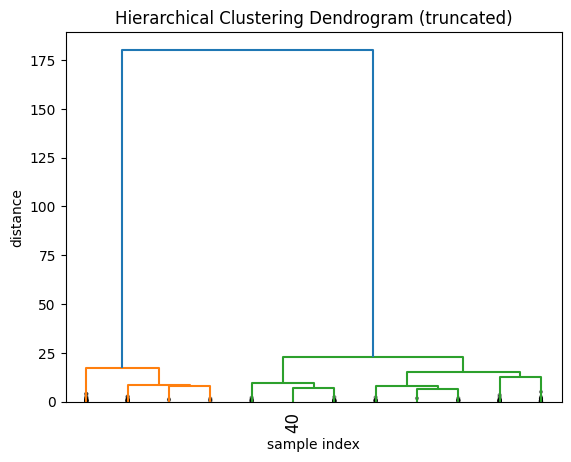

In [14]:
plt.title('Hierarchical Clustering Dendrogram (truncated)')
plt.xlabel('sample index')
plt.ylabel('distance')
dendrogram(
    Z,
    truncate_mode='lastp',  # show only the last p merged clusters
    p=12,  # show only the last p merged clusters
    show_leaf_counts=False,  # otherwise numbers in brackets are counts
    leaf_rotation=90.,
    leaf_font_size=12.,
    show_contracted=True,  # to get a distribution impression in truncated branches
)
plt.show()

The above shows a truncated dendrogram, which only shows the last p=12 out of our 149 merges.

First thing you should notice are that most labels are missing. This is because except for X[40] all other samples were already merged into clusters before the last 12 merges.

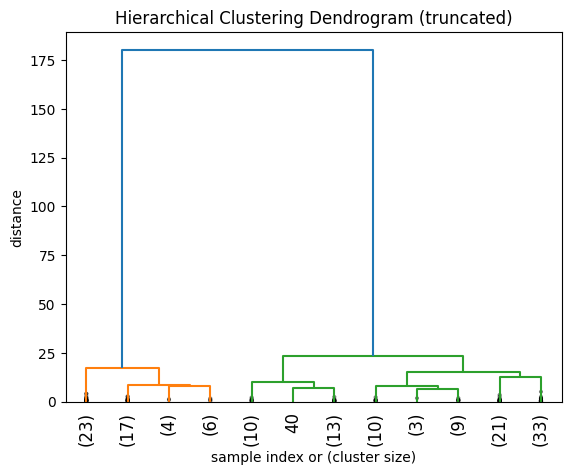

In [15]:
plt.title('Hierarchical Clustering Dendrogram (truncated)')
plt.xlabel('sample index or (cluster size)')
plt.ylabel('distance')
dendrogram(
    Z,
    truncate_mode='lastp',  # show only the last p merged clusters
    p=12,  # show only the last p merged clusters
    leaf_rotation=90.,
    leaf_font_size=12.,
    show_contracted=True,  # to get a distribution impression in truncated branches
)
plt.show()

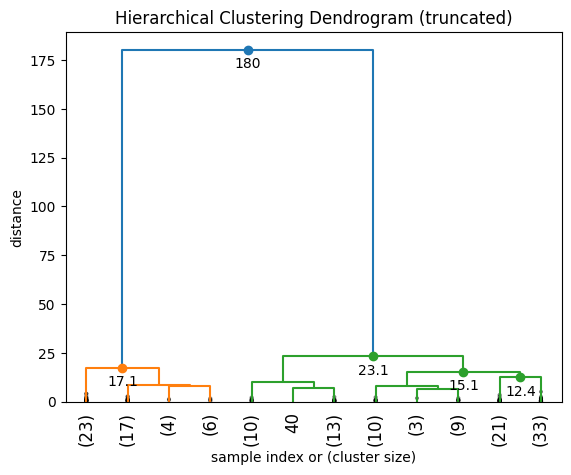

In [16]:
def fancy_dendrogram(*args, **kwargs):
    max_d = kwargs.pop('max_d', None)
    if max_d and 'color_threshold' not in kwargs:
        kwargs['color_threshold'] = max_d
    annotate_above = kwargs.pop('annotate_above', 0)

    ddata = dendrogram(*args, **kwargs)

    if not kwargs.get('no_plot', False):
        plt.title('Hierarchical Clustering Dendrogram (truncated)')
        plt.xlabel('sample index or (cluster size)')
        plt.ylabel('distance')
        for i, d, c in zip(ddata['icoord'], ddata['dcoord'], ddata['color_list']):
            x = 0.5 * sum(i[1:3])
            y = d[1]
            if y > annotate_above:
                plt.plot(x, y, 'o', c=c)
                plt.annotate("%.3g" % y, (x, y), xytext=(0, -5),
                             textcoords='offset points',
                             va='top', ha='center')
        if max_d:
            plt.axhline(y=max_d, c='k')
    return ddata


fancy_dendrogram(
    Z,
    truncate_mode='lastp',
    p=12,
    leaf_rotation=90.,
    leaf_font_size=12.,
    show_contracted=True,
    annotate_above=10,  # useful in small plots so annotations don't overlap
)
plt.show()

**selecting a distance cut-off aka determining the number of clusters:** 

As explained, a huge jump in distance is typicaally what is of interest if we want to argue for a certain number of clusters. 

In [17]:
# setting the cut-off to 50 in our example:
max_d = 50

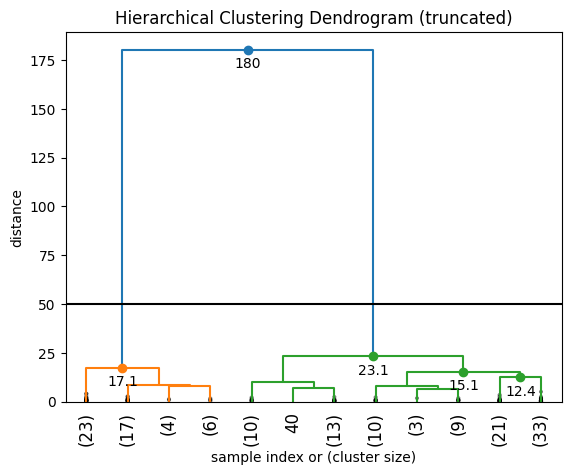

In [18]:
fancy_dendrogram(
    Z,
    truncate_mode='lastp',
    p=12,
    leaf_rotation=90.,
    leaf_font_size=12.,
    show_contracted=True,
    annotate_above=10,
    max_d=max_d,  # plot a horizontal cut-off line
)
plt.show()

**Retrieving clusters:**
- we use the fcluster function for this

**Knowing max_d:
- lets say we determined the maximum distance with the help of a dendrogram, then we can do the following to get the cluster_id for each of our samples:

In [19]:
from scipy.cluster.hierarchy import fcluster

In [20]:
max_d = 50
clusters = fcluster(Z, max_d, criterion='distance')
clusters

array([2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1], dtype=int32)

another way of retrieving cluster indices is by passing the number of clusters, k. | say, knowing we have k=2 clusters, we can use:

In [21]:
k = 2
fcluster(Z, k, criterion='maxclust')

array([2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1], dtype=int32)